# Chroma Embedding

This notebook visualizes harmonic similarity using the **fifth-aware** pitch-class function from `src/djprojectexploration/harmonic_compatibility.py`.

For 12-bin pitch-class vectors `x` and `y` (chromatic C order), similarity is computed as:

`s(x, y) = x^T K y`

where `K` is a circle-of-fifths kernel that gives highest weight to exact pitch-class matches, lower weight to first/second fifth neighbors, and near-zero weight to unrelated classes. In code this is built with `build_fifth_kernel(...)` and applied via `fifth_aware_similarity(...)` / `pairwise_fifth_aware_similarity_matrix(...)`.

Compared with naive cosine similarity on the embedding vector, this explicitly encodes tonal proximity on the circle of fifths, so harmonically related keys/chords are scored as more compatible.

In [1]:
from __future__ import annotations

import csv
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from djprojectexploration.harmonic_compatibility import (
    PITCH_CLASS_C_ORDER,
    build_fifth_kernel,
    pairwise_fifth_aware_similarity_matrix,
)


def to_project_relpath(path: Path) -> str:
    resolved = path.expanduser().resolve()
    try:
        return str(resolved.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(resolved)


print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/josephdaher/Git Repositories/djprojectexploration


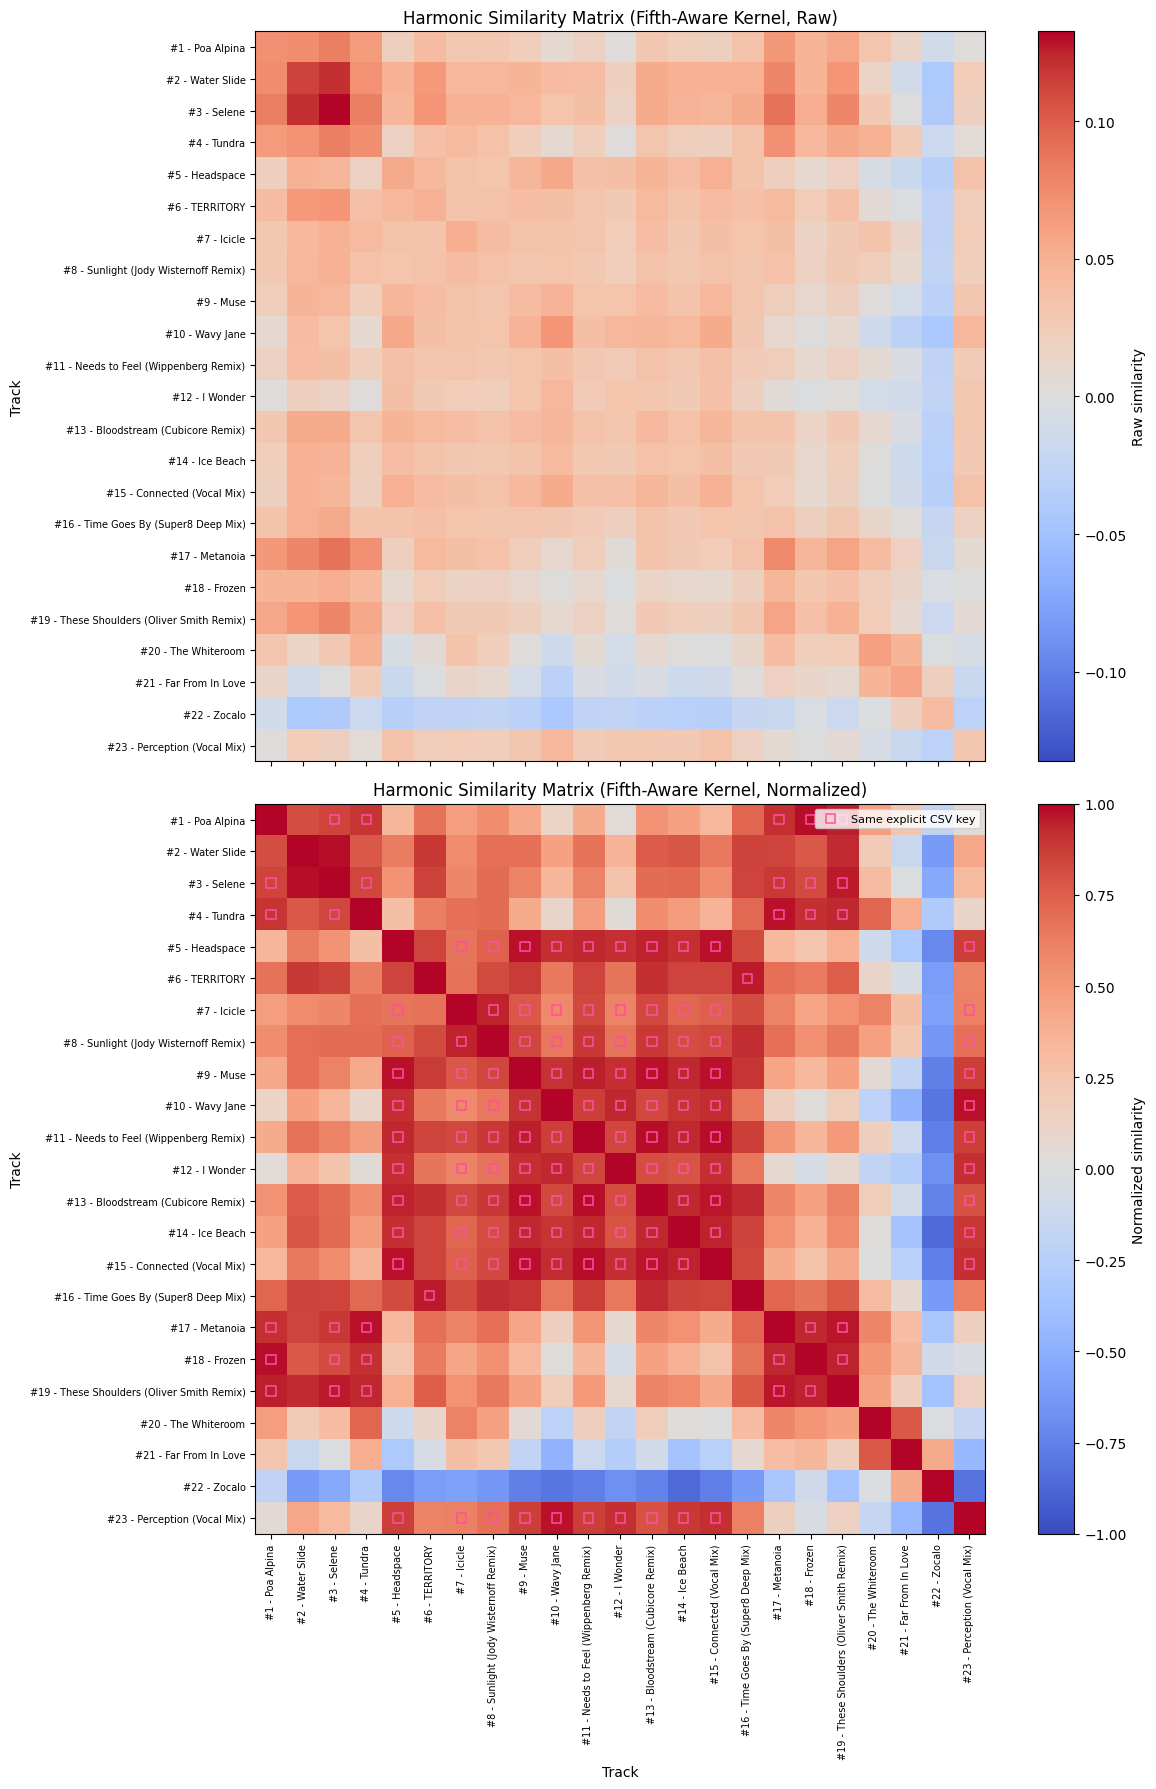

Loaded NPZ: data/chroma_embeddings/ara_mix_tracks.npz
Saved output: plot: data/chroma_embeddings/harmonic_similarity_fifth_aware_matrix.png
Saved output: matrix data: data/chroma_embeddings/harmonic_similarity_fifth_aware_matrix.npz
Tracks included: 23
Pink-square cells (same explicit CSV key): 142
Center baseline from NPZ: 0.083333 (used unit_sum_normalize=False)


In [3]:
TRACKLIST_CSV = PROJECT_ROOT / "music" / "ara-mix" / "ara_mix_tracks.csv"
CHROMA_DATA_DIR = PROJECT_ROOT / "data" / "chroma_embeddings"

if not TRACKLIST_CSV.exists():
    raise FileNotFoundError(f"Tracklist CSV not found: {TRACKLIST_CSV}")
if not CHROMA_DATA_DIR.exists():
    raise FileNotFoundError(f"Chroma embedding directory not found: {CHROMA_DATA_DIR}")

npz_name = TRACKLIST_CSV.stem if TRACKLIST_CSV.stem.endswith("_tracks") else f"{TRACKLIST_CSV.stem}_tracks"
CHROMA_NPZ_PATH = CHROMA_DATA_DIR / f"{npz_name}.npz"
if not CHROMA_NPZ_PATH.exists():
    raise FileNotFoundError(
        f"Chroma NPZ not found: {CHROMA_NPZ_PATH}\n"
        f"Generate it with: uv run djprojectexploration-chroma-playlist {to_project_relpath(TRACKLIST_CSV)} --music-dir {to_project_relpath(TRACKLIST_CSV.parent)}"
    )

# Essentia HPCP/chroma bin order used in this project
pitch_order_a = ["A", "A#", "B", "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#"]
pitch_order_c = list(PITCH_CLASS_C_ORDER)
a_to_c_idx = [pitch_order_a.index(label) for label in pitch_order_c]

with TRACKLIST_CSV.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    csv_rows = list(reader)

ordered_rows = []
for row in csv_rows:
    tn = (row.get("track_number") or row.get("#") or "").strip()
    mp3_name = (row.get("mp3_name") or "").strip()
    title = (row.get("title") or "").strip() or Path(mp3_name).stem
    explicit_key = (row.get("key") or "").strip().upper()
    if not tn or not mp3_name:
        continue
    try:
        track_num = int(tn)
    except ValueError:
        continue
    ordered_rows.append({
        "track_num": track_num,
        "title": title,
        "mp3_name": mp3_name,
        "explicit_key": explicit_key,
    })

ordered_rows.sort(key=lambda x: x["track_num"])
if not ordered_rows:
    raise RuntimeError("No usable rows found in tracklist CSV.")

npz = np.load(CHROMA_NPZ_PATH, allow_pickle=False)
required = {"embeddings", "filenames"}
missing_required = required.difference(npz.files)
if missing_required:
    raise KeyError(f"Missing required NPZ keys: {sorted(missing_required)} | available: {sorted(npz.files)}")

embeddings = np.asarray(npz["embeddings"], dtype=np.float32)
filenames = [str(x).strip().lower() for x in npz["filenames"]]
filename_to_idx = {name: i for i, name in enumerate(filenames)}

if embeddings.ndim != 2:
    raise ValueError(f"Expected 2D embeddings array, got shape {embeddings.shape}.")
if embeddings.shape[0] != len(filenames):
    raise ValueError("`filenames` length does not match number of embedding rows.")

chroma_base_dims = None
if "chroma_base_embedding_dimension" in npz.files:
    chroma_base_dims = np.asarray(npz["chroma_base_embedding_dimension"], dtype=np.int32).reshape(-1)

pitch_means = None
if "chroma_pitch_class_mean" in npz.files:
    pitch_means = np.asarray(npz["chroma_pitch_class_mean"], dtype=np.float32)
    if pitch_means.ndim != 2 or pitch_means.shape[0] != embeddings.shape[0]:
        raise ValueError("`chroma_pitch_class_mean` must have shape (N, 12) aligned to embeddings.")

center_baseline = np.nan
if "config_center_baseline" in npz.files:
    center_baseline = float(np.asarray(npz["config_center_baseline"]).reshape(-1)[0])

track_labels = []
track_keys = []
vectors_c = []
missing = []

for row in ordered_rows:
    key = row["mp3_name"].strip().lower()
    idx = filename_to_idx.get(key)
    if idx is None:
        missing.append(row["mp3_name"])
        continue

    if pitch_means is not None:
        vec_a = np.asarray(pitch_means[idx], dtype=np.float32).reshape(-1)
    else:
        emb = np.asarray(embeddings[idx], dtype=np.float32).reshape(-1)
        if chroma_base_dims is not None and idx < chroma_base_dims.size:
            base_dim = int(chroma_base_dims[idx])
        else:
            base_dim = int(emb.size)

        if base_dim < 12 or emb.size < 12:
            missing.append(row["mp3_name"])
            continue

        # Fallback for older NPZ files that do not store explicit pitch-class means.
        vec_a = emb[:12].astype(np.float32)

    if vec_a.size < 12:
        missing.append(row["mp3_name"])
        continue

    vec_c = vec_a[a_to_c_idx]

    vectors_c.append(vec_c)
    track_labels.append(f"#{row['track_num']} - {row['title']}")
    track_keys.append(row["explicit_key"])

if not vectors_c:
    raise RuntimeError("No valid 12-D pitch-class vectors were found.")

X = np.vstack(vectors_c).astype(np.float32)
K = build_fifth_kernel(exact_weight=1.0, first_fifth_weight=0.4, second_fifth_weight=0.15, other_weight=0.0)

# Centered vectors should not be renormalized by sum (sum is near zero after centering).
use_unit_sum_normalization = not np.isfinite(center_baseline)
S = pairwise_fifth_aware_similarity_matrix(X, kernel=K, unit_sum_normalize=use_unit_sum_normalization)

# Kernel-normalized similarity so self-similarity is 1.0 when possible.
diag = np.diag(S).astype(np.float32)
den = np.sqrt(np.outer(diag, diag)).astype(np.float32)
S_norm = np.divide(S, den, out=np.zeros_like(S), where=den > 0)
valid_diag = diag > 0
S_norm[np.diag_indices_from(S_norm)] = np.where(valid_diag, 1.0, 0.0)

if np.any(S < 0):
    raw_lim = float(np.max(np.abs(S))) if S.size else 1.0
    raw_cmap = "coolwarm"
    raw_vmin, raw_vmax = -raw_lim, raw_lim
else:
    raw_cmap = "viridis"
    raw_vmin, raw_vmax = 0.0, max(1.0, float(np.max(S)))

if np.any(S_norm < 0):
    norm_cmap = "coolwarm"
    norm_vmin, norm_vmax = -1.0, 1.0
else:
    norm_cmap = "viridis"
    norm_vmin, norm_vmax = 0.0, 1.0

fig, (ax_raw, ax_norm) = plt.subplots(2, 1, figsize=(14, 18), sharex=True, sharey=True)

im_raw = ax_raw.imshow(S, cmap=raw_cmap, vmin=raw_vmin, vmax=raw_vmax)
ax_raw.set_title("Harmonic Similarity Matrix (Fifth-Aware Kernel, Raw)")
ax_raw.set_ylabel("Track")
ax_raw.set_xticks(np.arange(len(track_labels)))
ax_raw.set_yticks(np.arange(len(track_labels)))
ax_raw.set_xticklabels(track_labels, rotation=90, fontsize=7)
ax_raw.set_yticklabels(track_labels, fontsize=7)
ax_raw.tick_params(axis="x", labelbottom=False)
fig.colorbar(im_raw, ax=ax_raw, fraction=0.046, pad=0.04, label="Raw similarity")

im_norm = ax_norm.imshow(S_norm, cmap=norm_cmap, vmin=norm_vmin, vmax=norm_vmax)
ax_norm.set_title("Harmonic Similarity Matrix (Fifth-Aware Kernel, Normalized)")
ax_norm.set_xlabel("Track")
ax_norm.set_ylabel("Track")
ax_norm.set_xticks(np.arange(len(track_labels)))
ax_norm.set_yticks(np.arange(len(track_labels)))
ax_norm.set_xticklabels(track_labels, rotation=90, fontsize=7)
ax_norm.set_yticklabels(track_labels, fontsize=7)
fig.colorbar(im_norm, ax=ax_norm, fraction=0.046, pad=0.04, label="Normalized similarity")

# Highlight cells where two different tracks share the same explicit CSV key label.
track_keys_arr = np.asarray(track_keys, dtype=object)
has_explicit_key = np.array([bool(k) for k in track_keys_arr], dtype=bool)
same_explicit_key_mask = (
    (track_keys_arr[:, None] == track_keys_arr[None, :])
    & has_explicit_key[:, None]
    & has_explicit_key[None, :]
)
np.fill_diagonal(same_explicit_key_mask, False)

same_key_cells = np.argwhere(same_explicit_key_mask)
if same_key_cells.size > 0:
    ax_norm.scatter(
        same_key_cells[:, 1],
        same_key_cells[:, 0],
        marker="s",
        s=45,
        facecolors="none",
        edgecolors="#FF4FA3",
        linewidths=1.1,
        label="Same explicit CSV key",
    )
    ax_norm.legend(loc="upper right", fontsize=8, frameon=True)

fig.tight_layout()

plot_path = CHROMA_DATA_DIR / "harmonic_similarity_fifth_aware_matrix.png"
fig.savefig(plot_path, dpi=220)
plt.show()

matrix_path = CHROMA_DATA_DIR / "harmonic_similarity_fifth_aware_matrix.npz"
np.savez_compressed(
    matrix_path,
    labels=np.array(track_labels),
    explicit_keys=np.array(track_keys, dtype=object),
    similarity_matrix=S,
    similarity_matrix_normalized=S_norm,
    same_explicit_key_mask=same_explicit_key_mask,
    kernel=K,
    pitch_order=np.array(pitch_order_c),
    center_baseline=np.array(center_baseline, dtype=np.float32),
    unit_sum_normalize=np.array(use_unit_sum_normalization, dtype=np.bool_),
    source_npz=np.array(str(CHROMA_NPZ_PATH), dtype=np.str_),
)

print(f"Loaded NPZ: {to_project_relpath(CHROMA_NPZ_PATH)}")
print(f"Saved output: plot: {to_project_relpath(plot_path)}")
print(f"Saved output: matrix data: {to_project_relpath(matrix_path)}")
print(f"Tracks included: {len(track_labels)}")
print(f"Pink-square cells (same explicit CSV key): {int(np.sum(same_explicit_key_mask))}")
if np.isfinite(center_baseline):
    print(f"Center baseline from NPZ: {center_baseline:.6f} (used unit_sum_normalize=False)")
else:
    print("Center baseline not found in NPZ metadata; used unit_sum_normalize=True.")
if missing:
    print(f"Missing/invalid embedding rows ({len(missing)}):")
    for name in missing:
        print(f"  - {name}")


## Interactive Chromagram Plotter (Notebook Version)

This section provides a fully notebook-native chromagram workflow.

Run cells in order:
1. `Chromagram Defaults`
2. `Compute Chromagram Data`
3. `Interactive Chromagram Figure`

Default parameters mirror the current analysis defaults (`sample_rate=44100`, `frame_size=4096`, `hop_size=1024`, `chroma_bins=12`) and use **TempoCNN** for beat timing by default.

Interactive controls:
- Horizontal zoom/pan with range slider + mouse wheel zoom
- Zoom preset buttons (`10s`, `30s`, `60s`, `Full`)
- Panel type selector for row-2 view (`chroma`, `beat pooled`, `spectrogram`)

TempoCNN notes:
- Model is resolved from `models/` (defaults include `models/deeptemp-k16-3.pb`)
- Default beat mode is `tempocnn_phase_aligned`
- Optional manual overrides are still available for BPM and onset anchor

In [ ]:
import librosa
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import essentia.standard as es
from essentia.standard import FrameGenerator, HPCP, MonoLoader, SpectralPeaks, Spectrum, Windowing

from djprojectexploration.chroma_embedding import (
    build_beat_grid_from_bpm,
    detect_first_onset,
    estimate_key,
)


def compute_chromagram(
    audio: np.ndarray,
    sample_rate: int,
    frame_size: int,
    hop_size: int,
    chroma_bins: int,
) -> np.ndarray:
    windowing = Windowing(type="hann")
    spectrum = Spectrum(size=frame_size)
    spectral_peaks = SpectralPeaks(
        sampleRate=sample_rate,
        minFrequency=40,
        maxFrequency=5000,
        maxPeaks=80,
        magnitudeThreshold=1e-5,
        orderBy="magnitude",
    )
    hpcp = HPCP(
        size=chroma_bins,
        sampleRate=sample_rate,
        referenceFrequency=440,
        minFrequency=40,
        maxFrequency=5000,
        harmonics=8,
        nonLinear=False,
        weightType="cosine",
    )

    frames: list[np.ndarray] = []
    for frame in FrameGenerator(audio, frameSize=frame_size, hopSize=hop_size, startFromZero=True):
        spec = spectrum(windowing(frame))
        freqs, mags = spectral_peaks(spec)
        if len(freqs) == 0:
            frames.append(np.zeros(chroma_bins, dtype=np.float32))
            continue
        frames.append(np.asarray(hpcp(freqs, mags), dtype=np.float32))

    if not frames:
        raise ValueError("No frames were generated from the input audio.")

    # Shape: [chroma_bins, time_frames]
    return np.vstack(frames).T


def compute_spectrogram_db(
    audio: np.ndarray,
    sample_rate: int,
    frame_size: int,
    hop_size: int,
    min_frequency: float = 20.0,
    top_db: float = 80.0,
) -> tuple[np.ndarray, np.ndarray]:
    windowing = Windowing(type="hann")
    spectrum = Spectrum(size=frame_size)

    spec_frames: list[np.ndarray] = []
    for frame in FrameGenerator(audio, frameSize=frame_size, hopSize=hop_size, startFromZero=True):
        spec = np.asarray(spectrum(windowing(frame)), dtype=np.float32)
        spec_frames.append(spec)

    if not spec_frames:
        raise ValueError("No frames were generated from the input audio.")

    # Shape: [freq_bins, time_frames]
    spectrogram = np.vstack(spec_frames).T
    freqs = np.linspace(0.0, sample_rate / 2.0, spectrogram.shape[0], dtype=np.float32)

    valid = freqs >= float(min_frequency)
    if not np.any(valid):
        raise ValueError("No spectrogram bins available above min_frequency.")

    spectrogram = spectrogram[valid, :]
    freqs = freqs[valid]

    eps = np.finfo(np.float32).eps
    spectrogram_db = 20.0 * np.log10(np.maximum(spectrogram, eps))
    max_db = float(np.max(spectrogram_db))
    spectrogram_db = np.clip(spectrogram_db, max_db - float(top_db), max_db).astype(np.float32)
    return spectrogram_db, freqs


def pool_chromagram_by_beats(
    chromagram: np.ndarray,
    sample_rate: int,
    hop_size: int,
    beat_times: np.ndarray,
    chroma_duration: float,
) -> tuple[np.ndarray, np.ndarray] | None:
    if beat_times.size == 0:
        return None

    num_bins, num_frames = chromagram.shape
    if num_frames == 0:
        return None

    frame_times = (np.arange(num_frames, dtype=np.float32) * hop_size) / sample_rate
    internal_beats = beat_times[(beat_times > 0.0) & (beat_times < chroma_duration)]
    interval_edges = np.concatenate(([0.0], internal_beats, [chroma_duration])).astype(np.float32)
    interval_edges = np.unique(interval_edges)
    if interval_edges.size < 2:
        return None

    pooled_frames: list[np.ndarray] = []
    for i in range(interval_edges.size - 1):
        start = float(interval_edges[i])
        end = float(interval_edges[i + 1])
        mask = (frame_times >= start) & (frame_times < end)
        if np.any(mask):
            pooled_frames.append(chromagram[:, mask].mean(axis=1))
        else:
            midpoint = (start + end) * 0.5
            nearest_idx = int(np.argmin(np.abs(frame_times - midpoint)))
            pooled_frames.append(chromagram[:, nearest_idx])

    pooled_chromagram = np.stack(pooled_frames, axis=1).astype(np.float32)
    return pooled_chromagram, interval_edges


def first_existing_path(candidates: list[Path]) -> Path:
    for c in candidates:
        resolved = c.expanduser().resolve()
        if resolved.exists():
            return resolved
    tried = [str(c.expanduser().resolve()) for c in candidates]
    raise FileNotFoundError(f"Could not find any candidate path. Tried: {tried}")


def build_tempcnn_beat_grid(
    audio: np.ndarray,
    sr: int,
    global_bpm: float,
    hop_length: int,
) -> tuple[np.ndarray, float, np.ndarray, np.ndarray]:
    if global_bpm <= 0:
        raise RuntimeError("TempoCNN returned non-positive BPM; cannot build beat grid.")

    beat_period = 60.0 / float(global_bpm)
    duration = len(audio) / float(sr)

    onset_env = librosa.onset.onset_strength(y=audio, sr=sr, hop_length=hop_length)
    onset_times = librosa.times_like(onset_env, sr=sr, hop_length=hop_length)

    n_phase = max(16, int(np.ceil(beat_period * sr / hop_length)))
    phase_candidates = np.linspace(0.0, beat_period, n_phase, endpoint=False)

    def phase_score(phase: float) -> float:
        beats = np.arange(phase, duration + beat_period, beat_period, dtype=np.float32)
        beats = beats[beats <= duration]
        if beats.size == 0:
            return -np.inf
        return float(np.sum(np.interp(beats, onset_times, onset_env)))

    scores = np.asarray([phase_score(float(p)) for p in phase_candidates], dtype=np.float32)
    best_phase = float(phase_candidates[int(np.argmax(scores))])

    beat_times = np.arange(best_phase, duration + beat_period, beat_period, dtype=np.float32)
    beat_times = beat_times[beat_times <= duration]

    if beat_times.size < 2:
        beat_times = np.arange(0.0, duration + beat_period, beat_period, dtype=np.float32)
        beat_times = beat_times[beat_times <= duration]

    return beat_times, best_phase, onset_env.astype(np.float32), onset_times.astype(np.float32)


# ----------------------------
# Notebook defaults / controls
# ----------------------------
CHROMA_AUDIO_CANDIDATES = [
    PROJECT_ROOT / "music" / "aries-mix" / "brainwasher.mp3",
    PROJECT_ROOT / "music" / "aries-mix" / "parasite.mp3",
    PROJECT_ROOT / "music" / "ara-mix" / "allnight.mp3",
]

TEMPOCNN_MODEL_CANDIDATES = [
    PROJECT_ROOT / "models" / "deeptemp-k16-3.pb",
    PROJECT_ROOT / "models" / "tempo" / "deeptemp-k16-3.pb",
]

CHROMA_OUTPUT_DIR = PROJECT_ROOT / "data" / "exports"
CHROMA_HTML_EXPORT = CHROMA_OUTPUT_DIR / "interactive_chromagram.html"

# Chroma/spectrogram analysis parameters
SAMPLE_RATE = 44100
FRAME_SIZE = 4096
HOP_SIZE = 1024
CHROMA_BINS = 12

SHOW_BEAT_POOLED = True
SHOW_LOG_SPECTROGRAM = True
SPECTROGRAM_MIN_FREQUENCY = 20.0
SPECTROGRAM_TOP_DB = 80.0

# TempoCNN parameters
TEMPOCNN_SAMPLE_RATE = 11025
TEMPOCNN_HOP_LENGTH = 256
TEMPOCNN_PATCH_HOP_SECONDS = 6.0
TEMPOCNN_PATCH_CENTER_SECONDS = 6.0

# Beat mode options:
# - "tempocnn_phase_aligned": TempoCNN BPM + phase aligned to onset strength (default)
# - "manual_bpm_first_onset": manual BPM + detected first onset anchor
# - "manual_bpm_manual_onset": manual BPM + MANUAL_ONSET_TIME_MS anchor
BEAT_GRID_MODE = "tempocnn_phase_aligned"
MANUAL_BPM = 124.0
MANUAL_ONSET_TIME_MS = 0.0

MAX_WAVE_POINTS = 140_000
INITIAL_WINDOW_SEC = 30.0
DEFAULT_PANEL_TYPE = "chroma"  # "chroma" | "pooled" | "spectrogram"

SAVE_INTERACTIVE_HTML = False

print("Chromagram notebook defaults loaded.")
print(f"Sample rate={SAMPLE_RATE}, frame={FRAME_SIZE}, hop={HOP_SIZE}, bins={CHROMA_BINS}")
print(f"TempoCNN sample_rate={TEMPOCNN_SAMPLE_RATE}, hop={TEMPOCNN_HOP_LENGTH}")


In [ ]:
audio_path = first_existing_path(CHROMA_AUDIO_CANDIDATES)
model_path = first_existing_path(TEMPOCNN_MODEL_CANDIDATES)

# Chroma/spectrogram audio stream
audio = MonoLoader(filename=str(audio_path), sampleRate=SAMPLE_RATE, resampleQuality=4)()
duration_sec = len(audio) / float(SAMPLE_RATE)

chromagram = compute_chromagram(
    audio=audio,
    sample_rate=SAMPLE_RATE,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
    chroma_bins=CHROMA_BINS,
)

spectrogram_db = None
spectrogram_freqs = None
if SHOW_LOG_SPECTROGRAM:
    spectrogram_db, spectrogram_freqs = compute_spectrogram_db(
        audio=audio,
        sample_rate=SAMPLE_RATE,
        frame_size=FRAME_SIZE,
        hop_size=HOP_SIZE,
        min_frequency=SPECTROGRAM_MIN_FREQUENCY,
        top_db=SPECTROGRAM_TOP_DB,
    )

# TempoCNN audio stream (model expects 11025 Hz)
audio_tc = MonoLoader(
    filename=str(audio_path),
    sampleRate=TEMPOCNN_SAMPLE_RATE,
    resampleQuality=4,
)()

global_bpm_tc, local_bpm_raw, local_prob_raw = es.TempoCNN(graphFilename=str(model_path))(audio_tc)
global_bpm_tc = float(global_bpm_tc)
local_bpm = np.asarray(local_bpm_raw, dtype=np.float32)
local_prob = np.asarray(local_prob_raw, dtype=np.float32)

beat_times_tc, beat_phase_sec_tc, onset_env_tc, onset_times_tc = build_tempcnn_beat_grid(
    audio=audio_tc,
    sr=TEMPOCNN_SAMPLE_RATE,
    global_bpm=global_bpm_tc,
    hop_length=TEMPOCNN_HOP_LENGTH,
)

n_local = int(min(local_bpm.size, local_prob.size))
local_bpm = local_bpm[:n_local]
local_prob = local_prob[:n_local]
if n_local > 0:
    local_bpm_times = (
        float(TEMPOCNN_PATCH_CENTER_SECONDS)
        + np.arange(n_local, dtype=np.float32) * float(TEMPOCNN_PATCH_HOP_SECONDS)
    )
    local_bpm_times = np.clip(local_bpm_times, 0.0, duration_sec).astype(np.float32)
else:
    local_bpm_times = np.array([], dtype=np.float32)

mode = str(BEAT_GRID_MODE).strip().lower()
if mode == "tempocnn_phase_aligned":
    detected_bpm = float(global_bpm_tc)
    beat_times = beat_times_tc.astype(np.float32)
    phase_anchor_sec = float(beat_phase_sec_tc)
    beat_source = "tempocnn_phase_aligned"
elif mode == "manual_bpm_first_onset":
    if MANUAL_BPM is None or float(MANUAL_BPM) <= 0:
        raise ValueError("manual modes require MANUAL_BPM > 0")
    phase_anchor_sec = detect_first_onset(audio)
    if phase_anchor_sec is None:
        phase_anchor_sec = 0.0
    detected_bpm = float(MANUAL_BPM)
    beat_times = build_beat_grid_from_bpm(
        audio_duration=duration_sec,
        bpm=detected_bpm,
        phase_anchor=float(phase_anchor_sec),
    ).astype(np.float32)
    beat_source = "manual_bpm_first_onset_anchor"
elif mode == "manual_bpm_manual_onset":
    if MANUAL_BPM is None or float(MANUAL_BPM) <= 0:
        raise ValueError("manual modes require MANUAL_BPM > 0")
    if MANUAL_ONSET_TIME_MS is None or float(MANUAL_ONSET_TIME_MS) < 0:
        raise ValueError("manual_bpm_manual_onset requires MANUAL_ONSET_TIME_MS >= 0")
    phase_anchor_sec = min(max(0.0, float(MANUAL_ONSET_TIME_MS) / 1000.0), duration_sec)
    detected_bpm = float(MANUAL_BPM)
    beat_times = build_beat_grid_from_bpm(
        audio_duration=duration_sec,
        bpm=detected_bpm,
        phase_anchor=phase_anchor_sec,
    ).astype(np.float32)
    beat_source = "manual_bpm_manual_onset_anchor"
else:
    raise ValueError(
        "BEAT_GRID_MODE must be one of: tempocnn_phase_aligned, manual_bpm_first_onset, manual_bpm_manual_onset"
    )

# Row-3 traces prefer TempoCNN local estimates.
if n_local > 0:
    local_bpm_values = local_bpm.astype(np.float32)
    local_activity = local_prob.astype(np.float32)
else:
    if beat_times.size < 2:
        local_bpm_times = np.array([], dtype=np.float32)
        local_bpm_values = np.array([], dtype=np.float32)
        local_activity = np.array([], dtype=np.float32)
    else:
        beat_intervals = np.diff(beat_times)
        valid = beat_intervals > 1e-6
        local_bpm_values = (60.0 / beat_intervals[valid]).astype(np.float32)
        local_bpm_times = (beat_times[:-1][valid] + 0.5 * beat_intervals[valid]).astype(np.float32)
        local_activity = np.zeros_like(local_bpm_values, dtype=np.float32)

beat_pooled_data = None
if SHOW_BEAT_POOLED:
    beat_pooled_data = pool_chromagram_by_beats(
        chromagram=chromagram,
        sample_rate=SAMPLE_RATE,
        hop_size=HOP_SIZE,
        beat_times=beat_times,
        chroma_duration=(chromagram.shape[1] * HOP_SIZE) / SAMPLE_RATE,
    )

detected_key, detected_scale, key_strength = estimate_key(
    audio=audio,
    sample_rate=SAMPLE_RATE,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

print(f"Audio file: {to_project_relpath(audio_path)}")
print(f"TempoCNN model: {to_project_relpath(model_path)}")
print(f"Duration: {duration_sec:.2f}s")
print(f"TempoCNN global BPM: {global_bpm_tc:.2f}")
print(f"TempoCNN local windows: {n_local}")
print(f"Beat source: {beat_source}")
if phase_anchor_sec is not None:
    print(f"Phase anchor: {phase_anchor_sec:.3f}s")
print(f"BPM used for beat grid: {float(detected_bpm):.2f}")
print(f"Detected beats: {beat_times.size}")
print(f"Chromagram shape: {chromagram.shape} [bins x frames]")
if spectrogram_db is not None:
    print(f"Spectrogram shape: {spectrogram_db.shape} [freq_bins x frames]")
print(f"Estimated key: {detected_key} {detected_scale} (strength={key_strength:.3f})")

In [ ]:
if 'chromagram' not in globals():
    raise RuntimeError('Run the compute cell first.')


def build_waveform_envelope(t: np.ndarray, y: np.ndarray, max_points: int = MAX_WAVE_POINTS):
    n = y.size
    if n <= max_points:
        return t.astype(np.float32), y.astype(np.float32), y.astype(np.float32), 'raw'

    bins = max(1, max_points // 2)
    bin_size = int(np.ceil(n / bins))
    padded = int(np.ceil(n / bin_size) * bin_size)

    if padded > n:
        pad_n = padded - n
        y_pad = np.pad(y, (0, pad_n), mode='edge')
        t_pad = np.pad(t, (0, pad_n), mode='edge')
    else:
        y_pad = y
        t_pad = t

    y2 = y_pad.reshape(-1, bin_size)
    t2 = t_pad.reshape(-1, bin_size)

    t_start = t2[:, 0].astype(np.float32)
    t_end = t2[:, -1].astype(np.float32)
    y_min = y2.min(axis=1).astype(np.float32)
    y_max = y2.max(axis=1).astype(np.float32)

    x_env = np.empty(t_start.size * 3, dtype=np.float32)
    y_env = np.empty(y_min.size * 3, dtype=np.float32)

    x_env[0::3] = t_start
    x_env[1::3] = t_end
    x_env[2::3] = np.nan

    y_env[0::3] = y_min
    y_env[1::3] = y_max
    y_env[2::3] = np.nan

    return x_env, y_min, y_max, 'envelope'


def build_vertical_lines(xs: np.ndarray, ymin: float, ymax: float):
    xs = np.asarray(xs, dtype=np.float32)
    if xs.size == 0:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)
    x = np.empty(xs.size * 3, dtype=np.float32)
    y = np.empty(xs.size * 3, dtype=np.float32)
    x[0::3] = xs
    x[1::3] = xs
    x[2::3] = np.nan
    y[0::3] = ymin
    y[1::3] = ymax
    y[2::3] = np.nan
    return x, y


time_sec = np.arange(audio.size, dtype=np.float32) / float(SAMPLE_RATE)
x_wave, y_min, y_max, wave_mode = build_waveform_envelope(time_sec, audio.astype(np.float32))

if wave_mode == 'raw':
    y_wave = y_max
else:
    y_wave = np.empty(y_min.size * 3, dtype=np.float32)
    y_wave[0::3] = y_min
    y_wave[1::3] = y_max
    y_wave[2::3] = np.nan

wave_ymin = float(np.min(audio)) if audio.size else -1.0
wave_ymax = float(np.max(audio)) if audio.size else 1.0

beat_x, beat_y = build_vertical_lines(beat_times, wave_ymin, wave_ymax)
downbeat_x, downbeat_y = build_vertical_lines(beat_times[::4], wave_ymin, wave_ymax)

chroma_time = np.arange(chromagram.shape[1], dtype=np.float32) * (HOP_SIZE / float(SAMPLE_RATE))
chroma_y = np.arange(chromagram.shape[0], dtype=np.float32)

pooled_chromagram = None
pooled_time = None
if beat_pooled_data is not None:
    pooled_chromagram, interval_edges = beat_pooled_data
    pooled_time = ((interval_edges[:-1] + interval_edges[1:]) * 0.5).astype(np.float32)

spec_time = None
spec_y = None
if spectrogram_db is not None and spectrogram_freqs is not None:
    spec_time = np.arange(spectrogram_db.shape[1], dtype=np.float32) * (HOP_SIZE / float(SAMPLE_RATE))
    spec_y = np.log2(np.maximum(spectrogram_freqs.astype(np.float32), 1e-6))

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    specs=[[{'secondary_y': False}], [{'secondary_y': False}], [{'secondary_y': True}]],
    subplot_titles=(
        f'Waveform + beat grid ({beat_source}) | BPM={float(detected_bpm):.2f}',
        'Chromatic panel (switch type with dropdown)',
        'TempoCNN local BPM + local probability',
    ),
)

# Row 1: waveform + beat overlays
fig.add_trace(
    go.Scattergl(
        x=x_wave,
        y=y_wave,
        mode='lines',
        name='waveform',
        line=dict(color='steelblue', width=1),
        hoverinfo='skip',
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scattergl(
        x=beat_x,
        y=beat_y,
        mode='lines',
        name='beats',
        line=dict(color='tomato', width=1),
        opacity=0.20,
        hoverinfo='skip',
        showlegend=False,
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scattergl(
        x=downbeat_x,
        y=downbeat_y,
        mode='lines',
        name='downbeats (every 4)',
        line=dict(color='red', width=1.2),
        opacity=0.35,
        hoverinfo='skip',
        showlegend=False,
    ),
    row=1,
    col=1,
)

# Row 2: type-switchable heatmaps

def panel_visible(name: str) -> tuple[bool, bool, bool]:
    n = str(name).lower()
    return (n == 'chroma', n == 'pooled', n == 'spectrogram')

show_chroma, show_pooled, show_spec = panel_visible(DEFAULT_PANEL_TYPE)
if pooled_chromagram is None:
    show_pooled = False
if spec_time is None:
    show_spec = False
if not (show_chroma or show_pooled or show_spec):
    show_chroma = True

fig.add_trace(
    go.Heatmap(
        x=chroma_time,
        y=chroma_y,
        z=chromagram,
        colorscale='Magma',
        colorbar=dict(title='Energy', x=1.02),
        zsmooth=False,
        visible=show_chroma,
        name='chroma',
    ),
    row=2,
    col=1,
)

if pooled_chromagram is not None and pooled_time is not None:
    pooled_z = pooled_chromagram
    pooled_x = pooled_time
else:
    pooled_z = np.zeros((CHROMA_BINS, 1), dtype=np.float32)
    pooled_x = np.array([0.0], dtype=np.float32)

fig.add_trace(
    go.Heatmap(
        x=pooled_x,
        y=np.arange(pooled_z.shape[0], dtype=np.float32),
        z=pooled_z,
        colorscale='Magma',
        colorbar=dict(title='Energy', x=1.02),
        zsmooth=False,
        visible=show_pooled,
        name='beat pooled',
    ),
    row=2,
    col=1,
)

if spec_time is not None and spec_y is not None and spectrogram_db is not None:
    spec_z = spectrogram_db
    spec_x = spec_time
    spec_yy = spec_y
else:
    spec_z = np.zeros((2, 1), dtype=np.float32)
    spec_x = np.array([0.0], dtype=np.float32)
    spec_yy = np.array([0.0, 1.0], dtype=np.float32)

fig.add_trace(
    go.Heatmap(
        x=spec_x,
        y=spec_yy,
        z=spec_z,
        colorscale='Viridis',
        colorbar=dict(title='dB', x=1.02),
        zsmooth=False,
        visible=show_spec,
        name='spectrogram',
    ),
    row=2,
    col=1,
)

# Row 3: local BPM and local probability
fig.add_trace(
    go.Scatter(
        x=local_bpm_times,
        y=local_bpm_values,
        mode='lines+markers',
        name='local BPM',
        line=dict(color='purple', width=2),
        marker=dict(size=6),
    ),
    row=3,
    col=1,
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=local_bpm_times,
        y=local_activity,
        mode='lines+markers',
        name='local probability',
        line=dict(color='darkgreen', width=2),
        marker=dict(size=5, symbol='square'),
    ),
    row=3,
    col=1,
    secondary_y=True,
)

initial_window = min(float(INITIAL_WINDOW_SEC), float(duration_sec))

def x_range_args(x0: float, x1: float):
    return {
        'xaxis.range': [x0, x1],
        'xaxis2.range': [x0, x1],
        'xaxis3.range': [x0, x1],
    }


def panel_visibility(name: str):
    ch, po, sp = panel_visible(name)
    if pooled_chromagram is None:
        po = False
    if spec_time is None:
        sp = False
    if not (ch or po or sp):
        ch = True
    return [True, True, True, ch, po, sp, True, True]

if CHROMA_BINS == 12:
    pitch_tickvals = list(range(12))
    pitch_ticktext = ['A', 'A#', 'B', 'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#']
else:
    pitch_tickvals = None
    pitch_ticktext = None

panel_layout_chroma = {
    'yaxis2': {
        'title': {'text': 'Pitch Class Bin'},
        'type': 'linear',
        'tickmode': 'array' if pitch_tickvals is not None else 'auto',
        'tickvals': pitch_tickvals,
        'ticktext': pitch_ticktext,
    }
}
panel_layout_pooled = panel_layout_chroma
panel_layout_spec = {
    'yaxis2': {
        'title': {'text': 'log2(Frequency Hz)'},
        'type': 'linear',
        'tickmode': 'auto',
    }
}

panel_buttons = [
    dict(
        label='Type: Chroma',
        method='update',
        args=[
            {'visible': panel_visibility('chroma')},
            panel_layout_chroma,
        ],
    ),
    dict(
        label='Type: Beat pooled',
        method='update',
        args=[
            {'visible': panel_visibility('pooled')},
            panel_layout_pooled,
        ],
    ),
    dict(
        label='Type: Spectrogram',
        method='update',
        args=[
            {'visible': panel_visibility('spectrogram')},
            panel_layout_spec,
        ],
    ),
]

zoom_buttons = [
    dict(label='10s', method='relayout', args=[x_range_args(0.0, min(10.0, duration_sec))]),
    dict(label='30s', method='relayout', args=[x_range_args(0.0, min(30.0, duration_sec))]),
    dict(label='60s', method='relayout', args=[x_range_args(0.0, min(60.0, duration_sec))]),
    dict(label='Full', method='relayout', args=[{'xaxis.autorange': True, 'xaxis2.autorange': True, 'xaxis3.autorange': True}]),
]

fig.update_layout(
    title=(
        f'Interactive Chromagram Inspector: {audio_path.name} | '
        f'Key={detected_key} {detected_scale} ({key_strength:.2f}) | '
        f'Beat source={beat_source}'
    ),
    height=980,
    template='plotly_white',
    hovermode='x unified',
    margin=dict(l=65, r=90, t=110, b=70),
    dragmode='pan',
    uirevision='chromagram-inspector-v2-tempocnn',
    updatemenus=[
        dict(
            type='buttons',
            direction='right',
            showactive=False,
            x=0.0,
            xanchor='left',
            y=1.16,
            yanchor='top',
            buttons=zoom_buttons,
        ),
        dict(
            type='dropdown',
            showactive=True,
            x=0.62,
            xanchor='left',
            y=1.16,
            yanchor='top',
            buttons=panel_buttons,
        ),
    ],
)

fig.update_xaxes(range=[0.0, initial_window], row=1, col=1)
fig.update_xaxes(title_text='Time (seconds)', rangeslider_visible=True, row=3, col=1)

fig.update_yaxes(title_text='Amplitude', fixedrange=True, row=1, col=1)
if show_spec:
    fig.update_yaxes(title_text='log2(Frequency Hz)', row=2, col=1)
else:
    fig.update_yaxes(title_text='Pitch Class Bin', row=2, col=1)
fig.update_yaxes(title_text='Local BPM', row=3, col=1, secondary_y=False)
fig.update_yaxes(
    title_text='Local probability',
    range=[0.0, 1.0],
    showgrid=False,
    row=3,
    col=1,
    secondary_y=True,
)

if CHROMA_BINS == 12 and not show_spec:
    fig.update_yaxes(
        tickmode='array',
        tickvals=list(range(12)),
        ticktext=['A', 'A#', 'B', 'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#'],
        row=2,
        col=1,
    )

if SAVE_INTERACTIVE_HTML:
    CHROMA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.write_html(str(CHROMA_HTML_EXPORT), include_plotlyjs='cdn', full_html=True)
    print(f"Saved interactive HTML: {to_project_relpath(CHROMA_HTML_EXPORT)}")

fig.show(config={'scrollZoom': True, 'displaylogo': False})

## Aries Mix Shift-Aware Harmonic Views

This block generates two Aries-mix diagnostics from chroma embeddings and key metadata:
1. **Circle-of-fifths Chroma View (Shift-Aware)**: applies each track's CSV `key shift` (semitones), reorders to circle-of-fifths pitch order, and overlays detected-key and CSV-key shifted root markers.
2. **Harmonic Compatibility Matrix (Normalized)**: computes fifth-aware pairwise similarity `x^T K y`, then kernel-normalizes by diagonal energy so self-similarity is 1 when defined.

**Key parameters/arguments used in the code cell:**
- `TRACKLIST_CSV_ARIES`: source tracklist (`music/aries-mix/aries_mix_tracks.csv`).
- `CHROMA_NPZ_ARIES`: NPZ feature collection (`data/chroma_embeddings/aries_mix_tracks.npz`).
- Fifth-aware kernel weights: `FIFTH_KERNEL_EXACT_WEIGHT`, `FIFTH_KERNEL_FIRST_WEIGHT`, `FIFTH_KERNEL_SECOND_WEIGHT`, `FIFTH_KERNEL_OTHER_WEIGHT`.
- `APPLY_KEY_SHIFT_TO_SIMILARITY`: when `True`, similarity is computed on key-shift-adjusted vectors (same shift rule as the chroma view).
- Similarity-axis labels use **CSV Camelot key tags** (e.g. `8A->9A`) instead of note-name keys.
- `USE_UNIT_SUM_NORMALIZATION_FOR_KERNEL`: auto-derived from `config_center_baseline`; if centered chroma is detected, unit-sum normalization is disabled.
- Output artifacts: Aries-specific PNG/NPZ/CSV files suffixed with `_aries_mix` to avoid overwriting ara-mix outputs.

- Matrix overlays: square = **same key** (includes diagonal), triangle = **one-off key** (e.g. `9A`/`8A`).


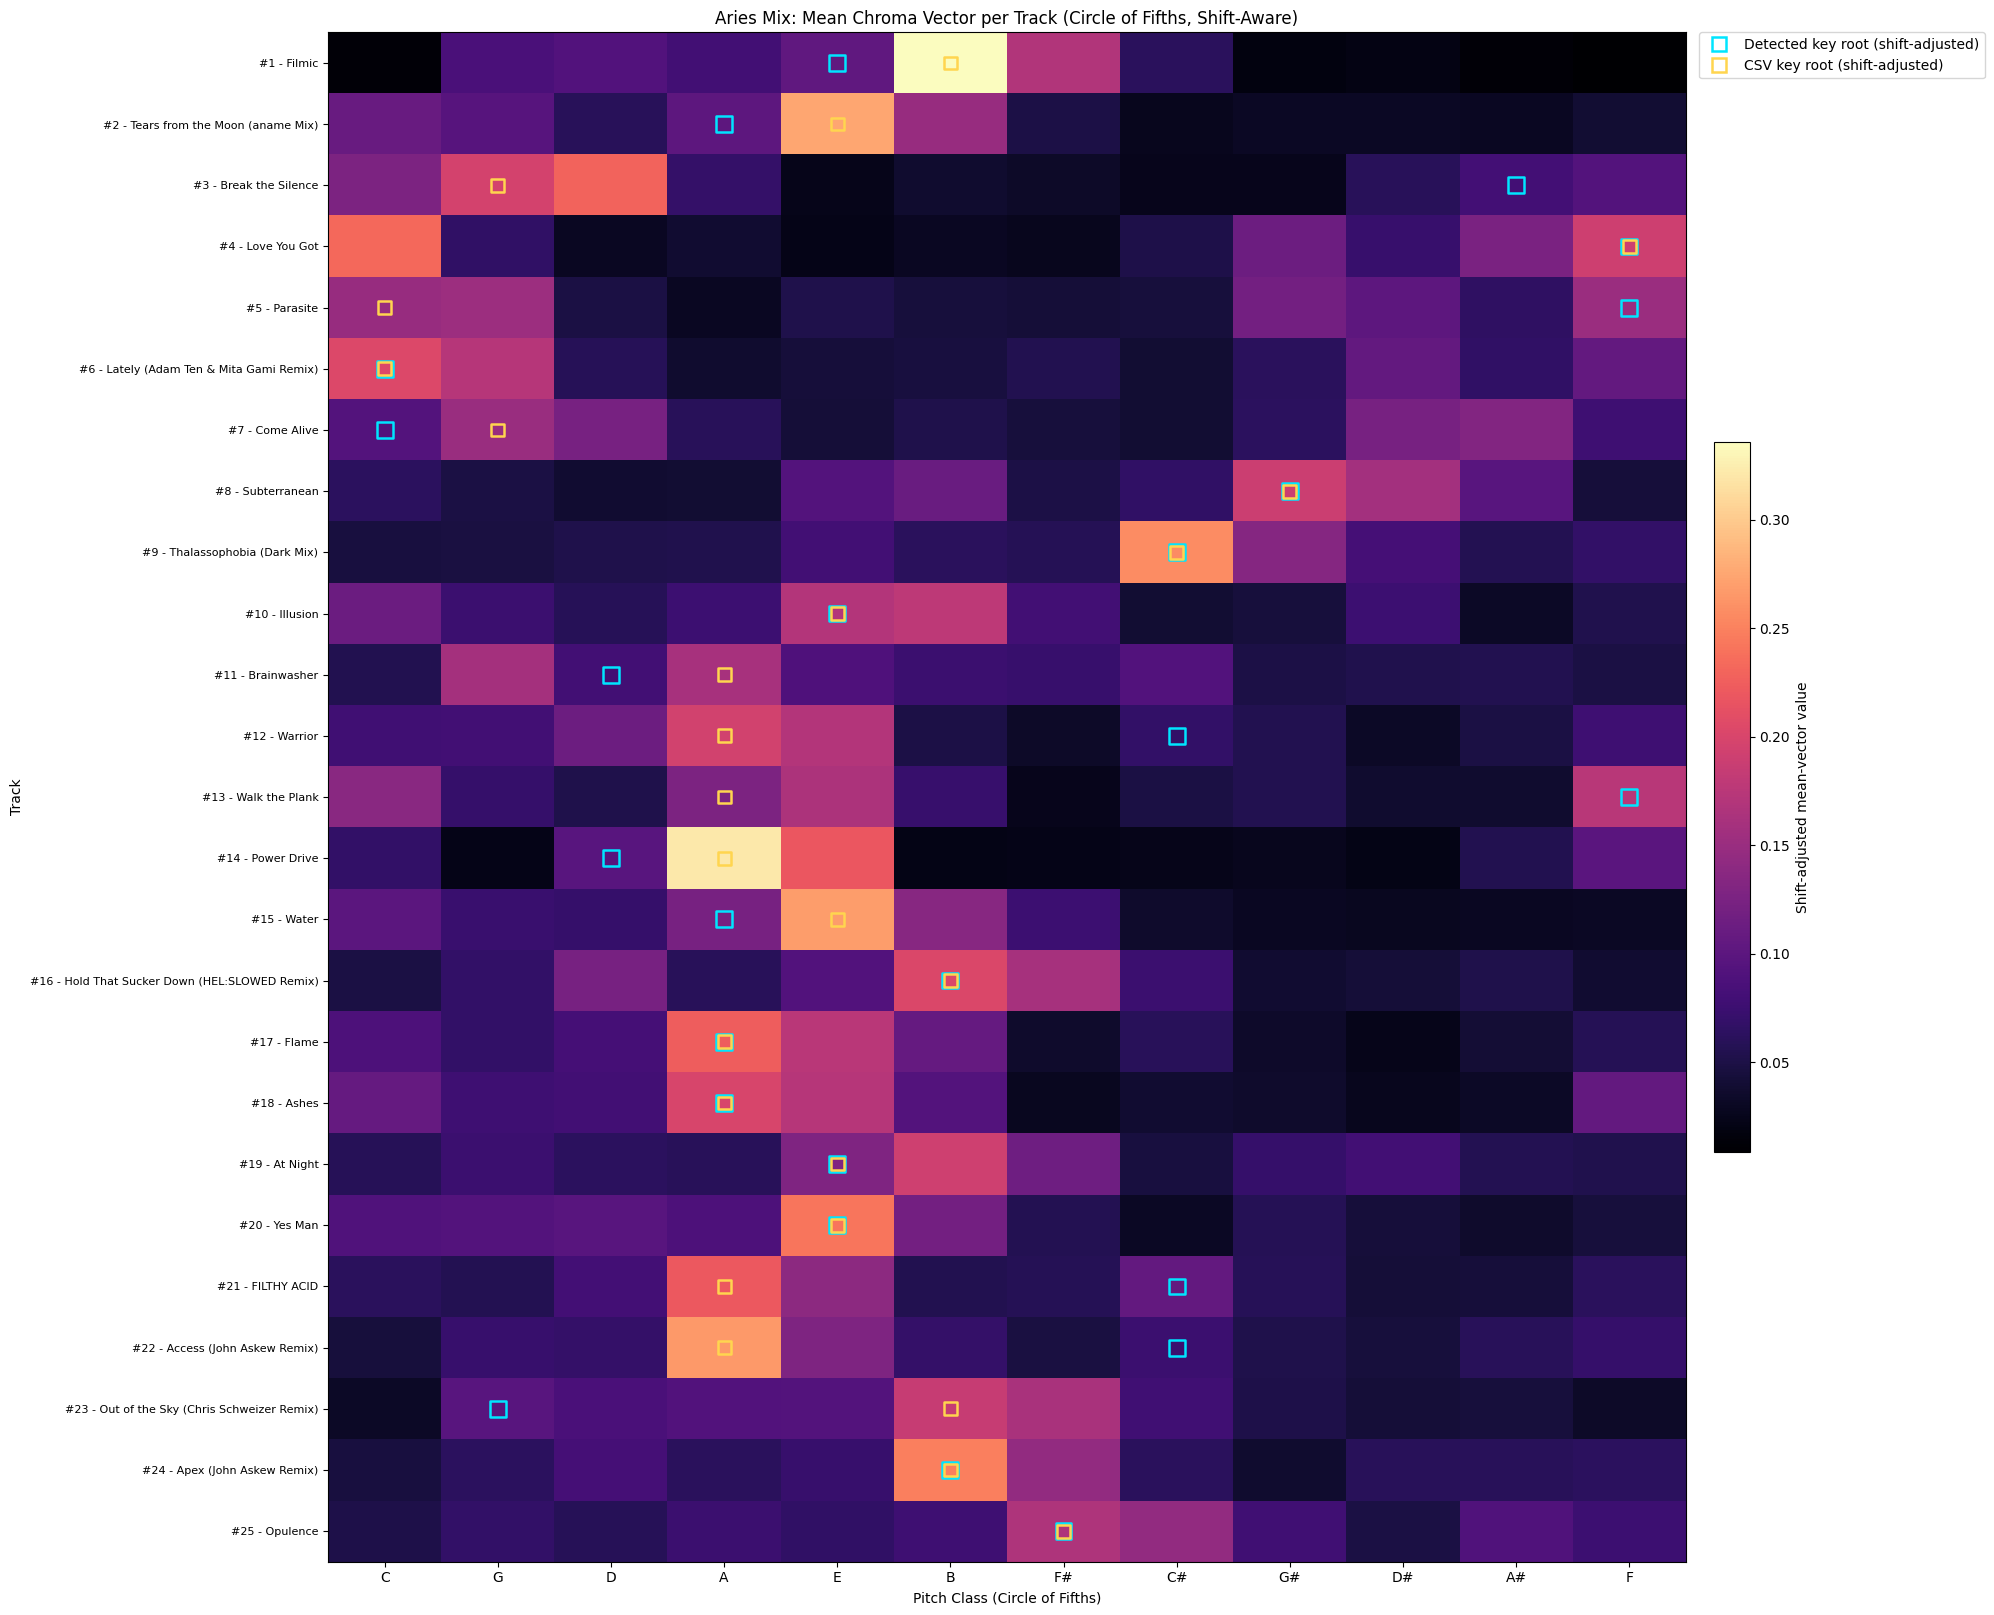

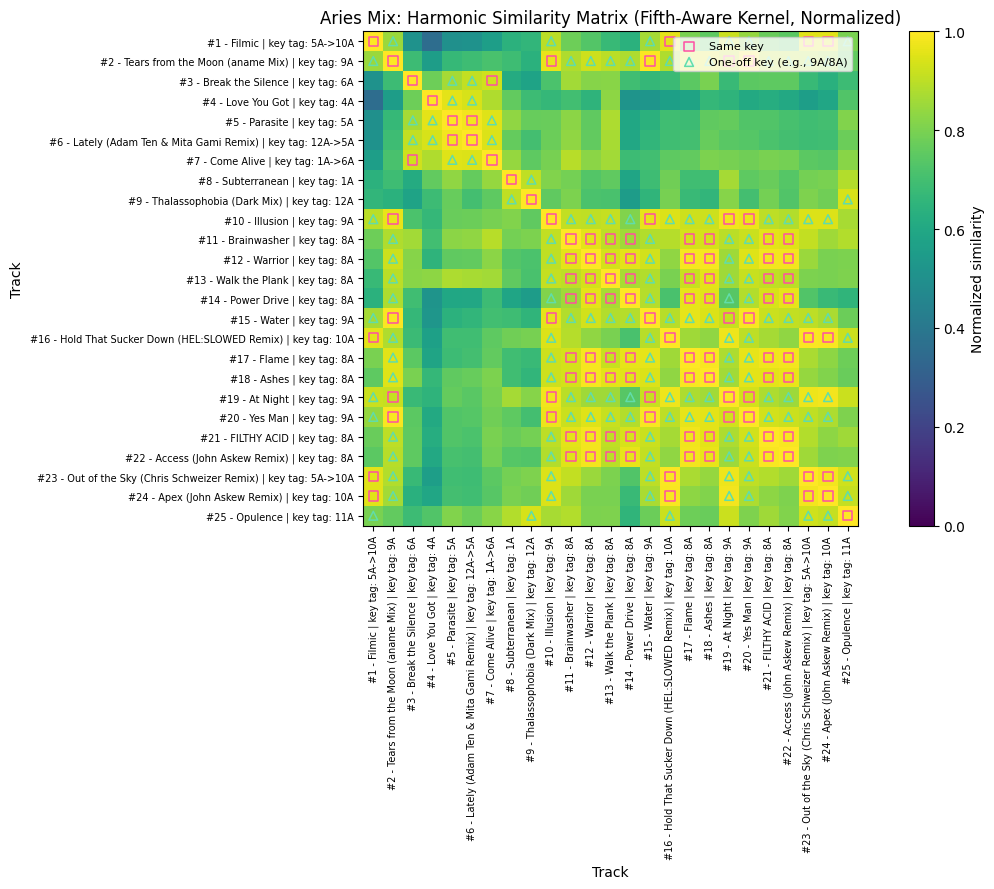

Aries mix shift-aware chroma and normalized harmonic matrix generated.
Loaded NPZ: data/chroma_embeddings/aries_mix_tracks.npz
Saved output: shift-aware plot: data/chroma_embeddings/chroma_mean_vectors_circle_of_fifths_shift_markers_aries_mix.png
Saved output: normalized matrix plot: data/chroma_embeddings/harmonic_similarity_fifth_aware_matrix_normalized_aries_mix.png
Saved output: matrix data: data/chroma_embeddings/harmonic_similarity_fifth_aware_matrix_aries_mix.npz
Saved output: detected-key table: data/chroma_embeddings/detected_keys_shift_adjusted_table_aries_mix.csv
Saved output: CSV-key table: data/chroma_embeddings/csv_keys_shift_adjusted_table_aries_mix.csv
Tracks included: 25
Square marker cells (same key, includes diagonal): 117
Triangle marker cells (one-off key): 144
APPLY_KEY_SHIFT_TO_SIMILARITY=True
Center baseline from NPZ: 0.083333 (used unit_sum_normalize=False)


In [7]:
# Aries Mix extension: shift-aware circle-of-fifths chroma view + normalized harmonic compatibility.
# Explanation:
# 1) Apply each track's CSV semitone key shift to 12-bin chroma means and plot in circle-of-fifths order.
# 2) Compute normalized fifth-aware harmonic similarity, using shift-adjusted vectors when configured.

from matplotlib.lines import Line2D

TRACKLIST_CSV_ARIES = PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv"
CHROMA_DATA_DIR = PROJECT_ROOT / "data" / "chroma_embeddings"

# Kernel / similarity parameters
FIFTH_KERNEL_EXACT_WEIGHT = 1.0
FIFTH_KERNEL_FIRST_WEIGHT = 0.4
FIFTH_KERNEL_SECOND_WEIGHT = 0.15
FIFTH_KERNEL_OTHER_WEIGHT = 0.0
APPLY_KEY_SHIFT_TO_SIMILARITY = True

if not TRACKLIST_CSV_ARIES.exists():
    raise FileNotFoundError(f"Tracklist CSV not found: {TRACKLIST_CSV_ARIES}")
if not CHROMA_DATA_DIR.exists():
    raise FileNotFoundError(f"Chroma embedding directory not found: {CHROMA_DATA_DIR}")

npz_name_aries = (
    TRACKLIST_CSV_ARIES.stem
    if TRACKLIST_CSV_ARIES.stem.endswith("_tracks")
    else f"{TRACKLIST_CSV_ARIES.stem}_tracks"
)
CHROMA_NPZ_ARIES = CHROMA_DATA_DIR / f"{npz_name_aries}.npz"
if not CHROMA_NPZ_ARIES.exists():
    raise FileNotFoundError(
        f"Chroma NPZ not found: {CHROMA_NPZ_ARIES}\n"
        f"Generate it with: uv run djprojectexploration-chroma-playlist {to_project_relpath(TRACKLIST_CSV_ARIES)} --music-dir {to_project_relpath(TRACKLIST_CSV_ARIES.parent)}"
    )

camelot_to_standard = {
    "1A": "G# minor",
    "2A": "D# minor",
    "3A": "A# minor",
    "4A": "F minor",
    "5A": "C minor",
    "6A": "G minor",
    "7A": "D minor",
    "8A": "A minor",
    "9A": "E minor",
    "10A": "B minor",
    "11A": "F# minor",
    "12A": "C# minor",
    "1B": "B major",
    "2B": "F# major",
    "3B": "C# major",
    "4B": "G# major",
    "5B": "D# major",
    "6B": "A# major",
    "7B": "F major",
    "8B": "C major",
    "9B": "G major",
    "10B": "D major",
    "11B": "A major",
    "12B": "E major",
}

pitch_order_a = ["A", "A#", "B", "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#"]
pitch_order_c = list(PITCH_CLASS_C_ORDER)
a_to_c_idx = [pitch_order_a.index(label) for label in pitch_order_c]

semitone_labels = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
circle_of_fifths_labels = ["C", "G", "D", "A", "E", "B", "F#", "C#", "G#", "D#", "A#", "F"]
label_to_idx_c = {label: i for i, label in enumerate(pitch_order_c)}
fifths_reorder_idx_c = [label_to_idx_c[label] for label in circle_of_fifths_labels]

enharmonic_root_map = {
    "CB": "B",
    "DB": "C#",
    "EB": "D#",
    "FB": "E",
    "GB": "F#",
    "AB": "G#",
    "BB": "A#",
    "E#": "F",
    "B#": "C",
}


def normalize_root(root: str | None) -> str | None:
    if root is None:
        return None
    token = str(root).strip().upper().replace("♯", "#").replace("♭", "B")
    if not token or token in {"N", "NA", "N/A", "UNKNOWN", "NONE"}:
        return None
    token = enharmonic_root_map.get(token, token)
    if token in semitone_labels:
        return token
    return None


def shift_root(root: str | None, semitone_shift: int) -> str | None:
    normalized = normalize_root(root)
    if normalized is None:
        return None
    idx = semitone_labels.index(normalized)
    return semitone_labels[(idx + int(semitone_shift)) % 12]


def convert_camelot_key(value: str) -> tuple[str | None, str | None, str]:
    if value is None:
        return None, None, "N/A"
    token = str(value).strip().upper()
    if len(token) < 2:
        return None, None, "N/A"
    wheel = token[:-1]
    ring = token[-1]
    if ring not in {"A", "B"}:
        return None, None, "N/A"
    try:
        wheel_num = int(wheel)
    except ValueError:
        return None, None, "N/A"
    normalized = f"{wheel_num}{ring}"
    standard = camelot_to_standard.get(normalized)
    if standard is None:
        return None, None, "N/A"
    parts = standard.split()
    if len(parts) < 2:
        return None, None, standard
    root = normalize_root(parts[0])
    mode = parts[1].lower()
    return root, mode, standard


def format_key(root: str | None, mode: str | None) -> str:
    if root is None:
        return "N/A"
    if mode is None:
        return root
    return f"{root} {mode}"


camelot_from_root_mode: dict[tuple[str, str], str] = {}
for tag, standard in camelot_to_standard.items():
    parts = str(standard).split()
    if len(parts) < 2:
        continue
    root_norm = normalize_root(parts[0])
    mode_norm = parts[1].lower()
    if root_norm is not None:
        camelot_from_root_mode[(root_norm, mode_norm)] = str(tag).upper()


def to_camelot_tag(root: str | None, mode: str | None) -> str | None:
    if root is None or mode is None:
        return None
    return camelot_from_root_mode.get((normalize_root(root), str(mode).lower()))


def parse_camelot_tag(tag: str | None) -> tuple[int, str] | None:
    if tag is None:
        return None
    token = str(tag).strip().upper()
    if len(token) < 2:
        return None
    ring = token[-1]
    wheel_txt = token[:-1]
    if ring not in {"A", "B"}:
        return None
    try:
        wheel = int(wheel_txt)
    except ValueError:
        return None
    if wheel < 1 or wheel > 12:
        return None
    return wheel, ring


def is_camelot_one_off(tag_i: str | None, tag_j: str | None) -> bool:
    pi = parse_camelot_tag(tag_i)
    pj = parse_camelot_tag(tag_j)
    if pi is None or pj is None:
        return False
    wi, ri = pi
    wj, rj = pj
    if ri != rj:
        return False
    d = abs(wi - wj)
    return d == 1 or d == 11


with TRACKLIST_CSV_ARIES.open("r", encoding="utf-8", newline="") as f:
    reader = csv.DictReader(f)
    csv_rows = list(reader)

ordered_rows = []
for row in csv_rows:
    tn = (row.get("track_number") or row.get("#") or "").strip()
    mp3_name = (row.get("mp3_name") or "").strip()
    title = (row.get("title") or "").strip() or Path(mp3_name).stem
    camelot = (row.get("key") or "").strip()
    explicit_key = camelot.upper()
    key_shift_raw = (row.get("key shift") or "0").strip()

    if not tn or not mp3_name:
        continue
    try:
        track_num = int(tn)
    except ValueError:
        continue

    try:
        key_shift = int(float(key_shift_raw))
    except ValueError:
        key_shift = 0

    ordered_rows.append(
        {
            "track_num": track_num,
            "title": title,
            "mp3_name": mp3_name,
            "camelot": camelot,
            "explicit_key": explicit_key,
            "key_shift": key_shift,
        }
    )

ordered_rows.sort(key=lambda x: x["track_num"])
if not ordered_rows:
    raise RuntimeError("No usable rows found in Aries mix tracklist CSV.")

npz = np.load(CHROMA_NPZ_ARIES, allow_pickle=False)
required = {"embeddings", "filenames"}
missing_required = required.difference(npz.files)
if missing_required:
    raise KeyError(f"Missing required NPZ keys: {sorted(missing_required)} | available: {sorted(npz.files)}")

embeddings = np.asarray(npz["embeddings"], dtype=np.float32)
filenames = [str(x).strip().lower() for x in npz["filenames"]]
filename_to_idx = {name: i for i, name in enumerate(filenames)}

chroma_base_dims = None
if "chroma_base_embedding_dimension" in npz.files:
    chroma_base_dims = np.asarray(npz["chroma_base_embedding_dimension"], dtype=np.int32).reshape(-1)

pitch_means = None
if "chroma_pitch_class_mean" in npz.files:
    pitch_means = np.asarray(npz["chroma_pitch_class_mean"], dtype=np.float32)

center_baseline = np.nan
if "config_center_baseline" in npz.files:
    center_baseline = float(np.asarray(npz["config_center_baseline"]).reshape(-1)[0])

USE_UNIT_SUM_NORMALIZATION_FOR_KERNEL = not np.isfinite(center_baseline)

detected_keys_arr = None
if "detected_key" in npz.files:
    detected_keys_arr = [str(x).strip() for x in npz["detected_key"]]

track_labels = []
track_labels_with_key = []
track_keys = []
track_key_tag_for_compare = []
vectors_c_for_similarity = []
mean_vectors_shifted_c = []
missing_rows = []

detected_shifted_roots = []
csv_shifted_roots = []
detected_table_rows = []
csv_table_rows = []

for row in ordered_rows:
    key = row["mp3_name"].strip().lower()
    idx = filename_to_idx.get(key)
    if idx is None:
        missing_rows.append(row["mp3_name"])
        continue

    if pitch_means is not None and pitch_means.ndim == 2 and idx < pitch_means.shape[0]:
        vec_a = np.asarray(pitch_means[idx], dtype=np.float32).reshape(-1)
    else:
        emb = np.asarray(embeddings[idx], dtype=np.float32).reshape(-1)
        if chroma_base_dims is not None and idx < chroma_base_dims.size:
            base_dim = int(chroma_base_dims[idx])
        else:
            base_dim = int(emb.size)
        if base_dim < 12 or emb.size < 12:
            missing_rows.append(row["mp3_name"])
            continue
        vec_a = emb[:12].astype(np.float32)

    if vec_a.size < 12:
        missing_rows.append(row["mp3_name"])
        continue

    if np.isfinite(center_baseline):
        vec_a_for_kernel = vec_a + float(center_baseline)
    else:
        vec_a_for_kernel = vec_a

    vec_a_for_kernel = np.clip(vec_a_for_kernel, 0.0, None)
    if float(np.sum(vec_a_for_kernel)) == 0.0:
        missing_rows.append(row["mp3_name"])
        continue

    vec_a_shifted = np.roll(vec_a_for_kernel, int(row["key_shift"]))
    vec_c_shifted = vec_a_shifted[a_to_c_idx]
    mean_vectors_shifted_c.append(vec_c_shifted)

    vec_a_similarity = vec_a_shifted if APPLY_KEY_SHIFT_TO_SIMILARITY else vec_a_for_kernel
    vec_c_similarity = vec_a_similarity[a_to_c_idx]
    vectors_c_for_similarity.append(vec_c_similarity)

    label = f"#{row['track_num']} - {row['title']}"
    track_labels.append(label)
    track_keys.append(row["explicit_key"])

    det_root_raw = None
    if detected_keys_arr is not None and idx < len(detected_keys_arr):
        det_root_raw = normalize_root(detected_keys_arr[idx])
    det_root_shifted = shift_root(det_root_raw, row["key_shift"])
    detected_shifted_roots.append(det_root_shifted)

    csv_root_raw, csv_mode, csv_standard = convert_camelot_key(row["camelot"])
    csv_root_shifted = shift_root(csv_root_raw, row["key_shift"])
    csv_shifted_roots.append(csv_root_shifted)

    csv_tag_raw = row["camelot"].strip().upper() or "N/A"
    csv_tag_shifted = to_camelot_tag(csv_root_shifted, csv_mode)
    if csv_tag_shifted is None:
        if csv_tag_raw != "N/A":
            csv_tag_shifted = f"{csv_tag_raw} (shift {row['key_shift']:+d})"
        else:
            csv_tag_shifted = "N/A"

    if csv_tag_raw != "N/A" and csv_tag_shifted != csv_tag_raw:
        key_tag_label = f"{csv_tag_raw}->{csv_tag_shifted}"
    else:
        key_tag_label = csv_tag_shifted

    # Use shifted Camelot key for similarity/key overlays whenever a valid shifted tag exists.
    if parse_camelot_tag(csv_tag_shifted) is not None:
        key_tag_for_compare = csv_tag_shifted
    elif parse_camelot_tag(csv_tag_raw) is not None:
        key_tag_for_compare = csv_tag_raw
    else:
        key_tag_for_compare = "N/A"
    track_key_tag_for_compare.append(key_tag_for_compare)

    track_labels_with_key.append(f"{label} | key tag: {key_tag_label}")

    detected_table_rows.append(
        {
            "track": label,
            "key_shift_semitones": row["key_shift"],
            "detected_raw": format_key(det_root_raw, None),
            "detected_shifted": format_key(det_root_shifted, None),
        }
    )

    csv_table_rows.append(
        {
            "track": label,
            "key_shift_semitones": row["key_shift"],
            "csv_camelot": row["camelot"],
            "csv_standard_raw": csv_standard,
            "csv_standard_shifted": csv_tag_shifted,
        }
    )

if not vectors_c_for_similarity:
    raise RuntimeError("No valid 12-D pitch-class vectors were found for Aries mix.")

# 1) Circle-of-fifths shift-aware chroma view
mean_matrix_shifted_c = np.vstack(mean_vectors_shifted_c).astype(np.float32)
mean_matrix_shifted_fifths = mean_matrix_shifted_c[:, fifths_reorder_idx_c]

n_tracks = mean_matrix_shifted_fifths.shape[0]
fig_shift, ax_shift = plt.subplots(figsize=(20, max(10, 0.45 * n_tracks + 5)))
im_shift = ax_shift.imshow(mean_matrix_shifted_fifths, aspect="auto", cmap="magma", interpolation="nearest")

ax_shift.set_title("Aries Mix: Mean Chroma Vector per Track (Circle of Fifths, Shift-Aware)")
ax_shift.set_xlabel("Pitch Class (Circle of Fifths)")
ax_shift.set_ylabel("Track")
ax_shift.set_xticks(np.arange(12))
ax_shift.set_xticklabels(circle_of_fifths_labels)
ax_shift.set_yticks(np.arange(n_tracks))
ax_shift.set_yticklabels(track_labels, fontsize=8)

for i, root in enumerate(detected_shifted_roots):
    if root in circle_of_fifths_labels:
        x = circle_of_fifths_labels.index(root)
        ax_shift.scatter(
            x,
            i,
            marker="s",
            s=130,
            facecolors="none",
            edgecolors="#00E5FF",
            linewidths=1.8,
            zorder=5,
        )

for i, root in enumerate(csv_shifted_roots):
    if root in circle_of_fifths_labels:
        x = circle_of_fifths_labels.index(root)
        ax_shift.scatter(
            x,
            i,
            marker="s",
            s=85,
            facecolors="none",
            edgecolors="#FFD54F",
            linewidths=1.8,
            zorder=6,
        )

legend_handles = [
    Line2D([0], [0], marker="s", color="none", markerfacecolor="none", markeredgecolor="#00E5FF", markeredgewidth=1.8, markersize=10, label="Detected key root (shift-adjusted)"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="none", markeredgecolor="#FFD54F", markeredgewidth=1.8, markersize=10, label="CSV key root (shift-adjusted)"),
]
ax_shift.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)

cb_shift = fig_shift.colorbar(im_shift, ax=ax_shift, fraction=0.025, pad=0.02)
cb_shift.set_label("Shift-adjusted mean-vector value")
fig_shift.tight_layout()

plot_shift_path = CHROMA_DATA_DIR / "chroma_mean_vectors_circle_of_fifths_shift_markers_aries_mix.png"
fig_shift.savefig(plot_shift_path, dpi=220, bbox_inches="tight")
plt.show()

# 2) Harmonic compatibility matrix (normalized)
X_c = np.vstack(vectors_c_for_similarity).astype(np.float32)
K = build_fifth_kernel(
    exact_weight=FIFTH_KERNEL_EXACT_WEIGHT,
    first_fifth_weight=FIFTH_KERNEL_FIRST_WEIGHT,
    second_fifth_weight=FIFTH_KERNEL_SECOND_WEIGHT,
    other_weight=FIFTH_KERNEL_OTHER_WEIGHT,
)
S = pairwise_fifth_aware_similarity_matrix(
    X_c,
    kernel=K,
    unit_sum_normalize=USE_UNIT_SUM_NORMALIZATION_FOR_KERNEL,
)

diag = np.diag(S).astype(np.float32)
den = np.sqrt(np.outer(diag, diag)).astype(np.float32)
S_norm = np.divide(S, den, out=np.zeros_like(S), where=den > 0)
valid_diag = diag > 0
S_norm[np.diag_indices_from(S_norm)] = np.where(valid_diag, 1.0, 0.0)

if np.any(S_norm < 0):
    norm_cmap = "coolwarm"
    norm_vmin, norm_vmax = -1.0, 1.0
else:
    norm_cmap = "viridis"
    norm_vmin, norm_vmax = 0.0, 1.0

fig_norm, ax_norm = plt.subplots(figsize=(14, 9))
im_norm = ax_norm.imshow(S_norm, cmap=norm_cmap, vmin=norm_vmin, vmax=norm_vmax)
ax_norm.set_title("Aries Mix: Harmonic Similarity Matrix (Fifth-Aware Kernel, Normalized)")
ax_norm.set_xlabel("Track")
ax_norm.set_ylabel("Track")
ax_norm.set_xticks(np.arange(len(track_labels_with_key)))
ax_norm.set_yticks(np.arange(len(track_labels_with_key)))
ax_norm.set_xticklabels(track_labels_with_key, rotation=90, fontsize=7)
ax_norm.set_yticklabels(track_labels_with_key, fontsize=7)
fig_norm.colorbar(im_norm, ax=ax_norm, fraction=0.046, pad=0.04, label="Normalized similarity")

track_key_tags_arr = np.asarray(track_key_tag_for_compare, dtype=object)
has_key_tag = np.array([parse_camelot_tag(k) is not None for k in track_key_tags_arr], dtype=bool)

# Same-key mask uses shifted Camelot tags when available and includes diagonal cells.
same_key_mask = (
    (track_key_tags_arr[:, None] == track_key_tags_arr[None, :])
    & has_key_tag[:, None]
    & has_key_tag[None, :]
)

# One-off mask (e.g., 9A/8A or 8A/7A), same ring, +/-1 wheel step, excluding same-key cells.
n_tracks_key = track_key_tags_arr.shape[0]
adjacent_one_off_key_mask = np.zeros((n_tracks_key, n_tracks_key), dtype=bool)
for i in range(n_tracks_key):
    for j in range(n_tracks_key):
        if i == j:
            continue
        if not has_key_tag[i] or not has_key_tag[j]:
            continue
        if is_camelot_one_off(track_key_tags_arr[i], track_key_tags_arr[j]):
            adjacent_one_off_key_mask[i, j] = True
adjacent_one_off_key_mask &= ~same_key_mask

legend_handles_norm = []

same_key_cells = np.argwhere(same_key_mask)
if same_key_cells.size > 0:
    ax_norm.scatter(
        same_key_cells[:, 1],
        same_key_cells[:, 0],
        marker="s",
        s=45,
        facecolors="none",
        edgecolors="#FF4FA3",
        linewidths=1.1,
        label="Same key",
    )
    legend_handles_norm.append("same")

one_off_cells = np.argwhere(adjacent_one_off_key_mask)
if one_off_cells.size > 0:
    ax_norm.scatter(
        one_off_cells[:, 1],
        one_off_cells[:, 0],
        marker="^",
        s=40,
        facecolors="none",
        edgecolors="#61DDAA",
        linewidths=1.1,
        label="One-off key (e.g., 9A/8A)",
    )
    legend_handles_norm.append("one_off")

if legend_handles_norm:
    ax_norm.legend(loc="upper right", fontsize=8, frameon=True)

fig_norm.tight_layout()
plot_norm_path = CHROMA_DATA_DIR / "harmonic_similarity_fifth_aware_matrix_normalized_aries_mix.png"
fig_norm.savefig(plot_norm_path, dpi=220)
plt.show()

matrix_path = CHROMA_DATA_DIR / "harmonic_similarity_fifth_aware_matrix_aries_mix.npz"
np.savez_compressed(
    matrix_path,
    labels=np.array(track_labels),
    labels_with_shifted_key=np.array(track_labels_with_key),
    explicit_keys=np.array(track_keys, dtype=object),
    similarity_matrix=S,
    similarity_matrix_normalized=S_norm,
    same_key_mask=same_key_mask,
    adjacent_one_off_key_mask=adjacent_one_off_key_mask,
    key_tags_for_compare=np.array(track_key_tag_for_compare, dtype=object),
    same_explicit_key_mask=same_key_mask,
    kernel=K,
    pitch_order=np.array(pitch_order_c),
    center_baseline=np.array(center_baseline, dtype=np.float32),
    unit_sum_normalize=np.array(USE_UNIT_SUM_NORMALIZATION_FOR_KERNEL, dtype=np.bool_),
    apply_key_shift_to_similarity=np.array(APPLY_KEY_SHIFT_TO_SIMILARITY, dtype=np.bool_),
    source_npz=np.array(str(CHROMA_NPZ_ARIES), dtype=np.str_),
)

detected_csv_path = CHROMA_DATA_DIR / "detected_keys_shift_adjusted_table_aries_mix.csv"
csv_keys_csv_path = CHROMA_DATA_DIR / "csv_keys_shift_adjusted_table_aries_mix.csv"

with detected_csv_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["track", "key_shift_semitones", "detected_raw", "detected_shifted"],
    )
    writer.writeheader()
    writer.writerows(detected_table_rows)

with csv_keys_csv_path.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["track", "key_shift_semitones", "csv_camelot", "csv_standard_raw", "csv_standard_shifted"],
    )
    writer.writeheader()
    writer.writerows(csv_table_rows)

print("Aries mix shift-aware chroma and normalized harmonic matrix generated.")
print(f"Loaded NPZ: {to_project_relpath(CHROMA_NPZ_ARIES)}")
print(f"Saved output: shift-aware plot: {to_project_relpath(plot_shift_path)}")
print(f"Saved output: normalized matrix plot: {to_project_relpath(plot_norm_path)}")
print(f"Saved output: matrix data: {to_project_relpath(matrix_path)}")
print(f"Saved output: detected-key table: {to_project_relpath(detected_csv_path)}")
print(f"Saved output: CSV-key table: {to_project_relpath(csv_keys_csv_path)}")
print(f"Tracks included: {len(track_labels)}")
print(f"Square marker cells (same key, includes diagonal): {int(np.sum(same_key_mask))}")
print(f"Triangle marker cells (one-off key): {int(np.sum(adjacent_one_off_key_mask))}")
print(f"APPLY_KEY_SHIFT_TO_SIMILARITY={APPLY_KEY_SHIFT_TO_SIMILARITY}")
if np.isfinite(center_baseline):
    print(f"Center baseline from NPZ: {center_baseline:.6f} (used unit_sum_normalize={USE_UNIT_SUM_NORMALIZATION_FOR_KERNEL})")
else:
    print(f"Center baseline not found in NPZ metadata; used unit_sum_normalize={USE_UNIT_SUM_NORMALIZATION_FOR_KERNEL}.")
if missing_rows:
    print(f"Missing/invalid embedding rows ({len(missing_rows)}):")
    for name in missing_rows:
        print(f"  - {name}")
